<a href="https://colab.research.google.com/github/Mymudh/AIML_projects_and_labs/blob/main/AIML_Module_01_Lab_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Extracting features from data

Module 1, Lab 1<br>



In [ ]:
!pip install wikipedia
import wikipedia
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import re
import unicodedata
import plotly.express as px
import pandas as pd
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Part 1: Features of text
How do we apply machine learning on text? We can't directly use the text as input to our algorithms. We need to convert them to features. In this notebook, we will explore a simple way of converting text to features.

Let us download a few documents off Wikipedia.

In [ ]:
topic1 = "Giraffe"
topic2 = "Elephant"
wikipedia.set_lang("en")
eng1 = wikipedia.page(topic1).content
eng2 = wikipedia.page(topic2).content
wikipedia.set_lang("fr")
fr1 = wikipedia.page("Girafe").content
fr2 = wikipedia.page("Éléphant").content

This is what the text looks like:

In [ ]:
fr2

'Les éléphants sont des mammifères proboscidiens de la famille des Éléphantidés. Ils correspondent aujourd\'hui à trois espèces réparties en deux genres distincts. L\'éléphant de savane d\'Afrique et l\'éléphant de forêt d\'Afrique, autrefois regroupés sous la même espèce d\'« éléphant d\'Afrique », appartiennent au genre Loxodonta, tandis que l\'éléphant d\'Asie, anciennement appelé « éléphant indien », appartient au genre Elephas. Ils se différencient par certaines caractéristiques anatomiques, les éléphants d\'Asie étant en général plus petits avec des oreilles plus petites, ou encore une différence du bout de la trompe. Ces espèces survivantes font localement l\'objet de programmes ou de projets de réintroduction et de protection.\nLe mot français « éléphant » vient du mot latin elephantus qui tire son origine du grec ἐλέφας / eléphas, « ivoire » ou « éléphant ».\nL\'éléphant apparait dans de nombreuses cultures. Il est symbole de sagesse dans la culture asiatique, connu pour sa mé

We need to clean this up a bit. Let us remove all the special characters and keep only 26 letters and space. Note that this will remove accented characters in French also. We are also removing all the numbers and spaces. So this is not an ideal solution.

In [ ]:
def cleanup(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = text.strip()
    return text

In [ ]:
eng1, eng2 = cleanup(eng1), cleanup(eng2)
fr1, fr2 = cleanup(fr1), cleanup(fr2)

In [ ]:
print(eng1[:500])

giraffesgenusgiraffaarelargeafricanhoofedmammalstheyarethetallestlivingterrestrialanimalsandthelargestruminantsonearththeyareclassifiedunderthefamilygiraffidaealongwiththeirclosestextantrelativetheokapitraditionallygiraffeshavebeenthoughtofasonespeciesgiraffacamelopardaliswithninesubspeciesmostrecentlyresearchersproposeddividingthemintofourextantspecieswithsevensubspecieswhichcanbedistinguishedmorphologicallybytheirfurcoatpatternssixvalidextinctspeciesofgiraffaareknownfromthefossilrecordthedisti


Now let us calculate the frequency of the character n-grams. N-grams are groups of characters of size n. A unigram is a single character and a bigram is a group of two characters and so on.

Let us count the frequency of each character in a text and plot it in a histogram.

In [ ]:
def tuple2string(tup):
    return ''.join(tup)
def key2string(keys):
    return [tuple2string(i) for i in keys]
def plothistogram(ngram):
    keys = key2string(ngram.keys())
    values = list(ngram.values())
    total = sum(values)
    values = [v / total for v in values]
    combined = sorted(zip(keys, values), key=lambda x: x[0])
    keys, values = zip(*combined)
    plt.bar(keys, values)
    plt.ylabel("Normalized Frequency")
    plt.show()

Let us compare the histograms of English pages and French pages. Can you spot a difference?

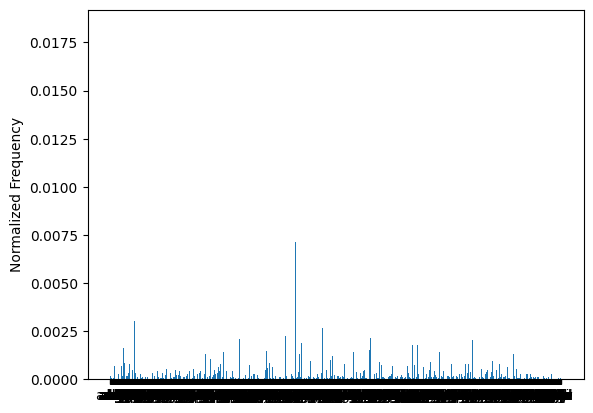

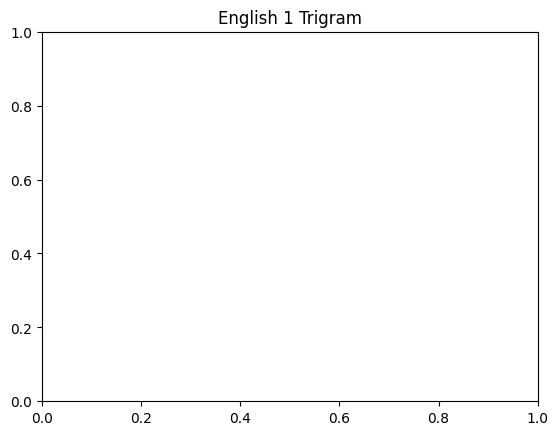

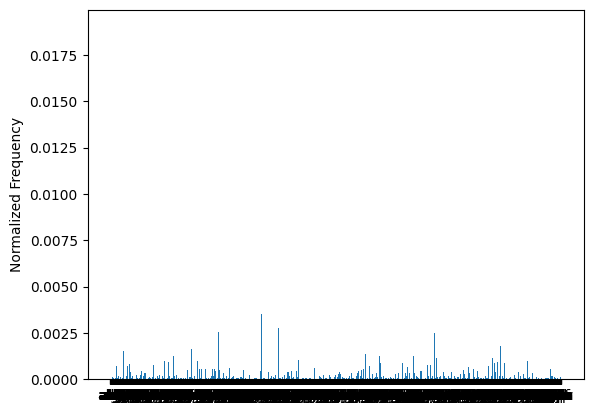

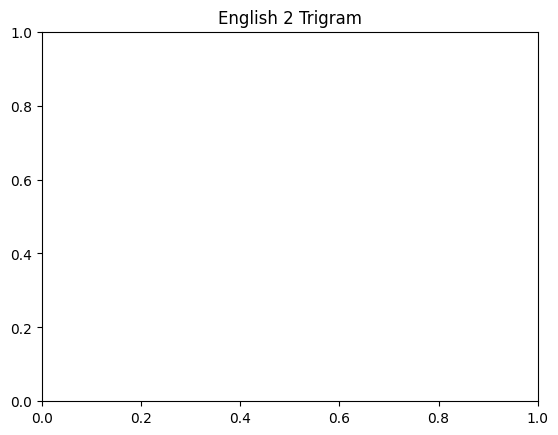

In [ ]:
trigram_eng1 = Counter(ngrams(eng1, 3))
plothistogram(trigram_eng1)
plt.title("English 1 Trigram")
plt.show()
trigram_eng2 = Counter(ngrams(eng2, 3))
plothistogram(trigram_eng2)
plt.title("English 2 Trigram")
plt.show()

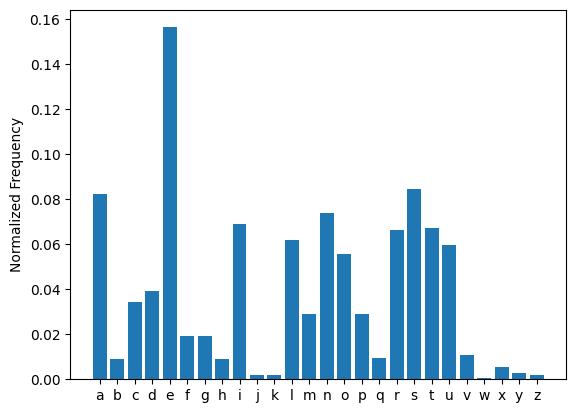

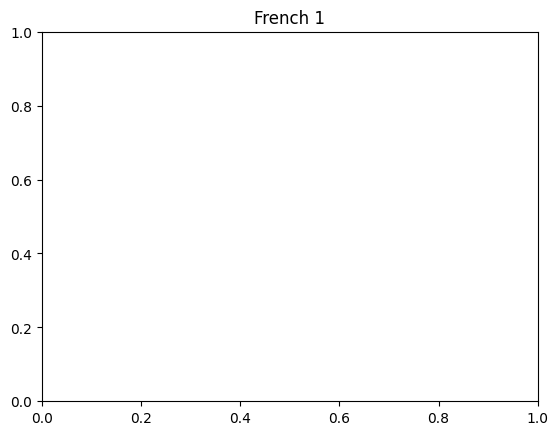

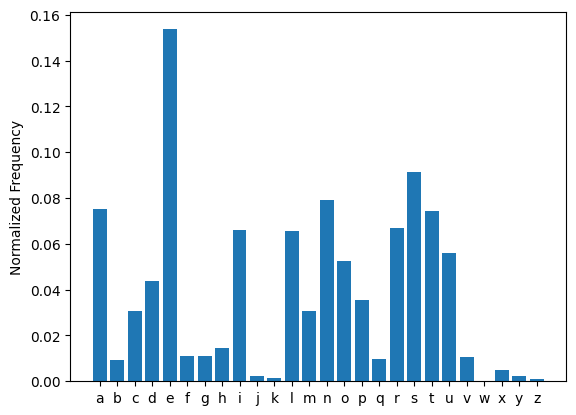

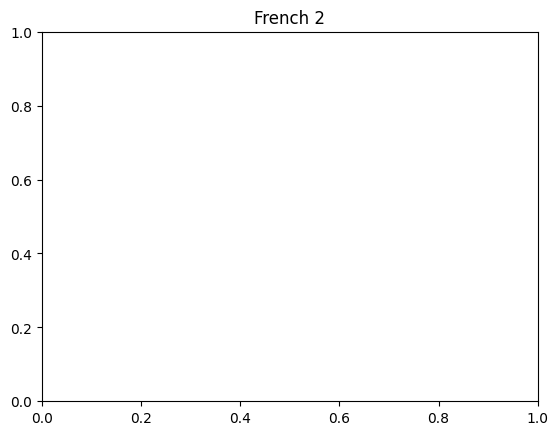

In [ ]:
unigram_fr1 = Counter(ngrams(fr1, 1))
plothistogram(unigram_fr1)
plt.title("French 1")
plt.show()
unigram_fr2 = Counter(ngrams(fr2, 1))
plothistogram(unigram_fr2)
plt.title("French 2")
plt.show()

We can see that the unigrams for French and English are very similar. So this is not a good feature if we want to distinguish between English and French. Let us look at bigrams.

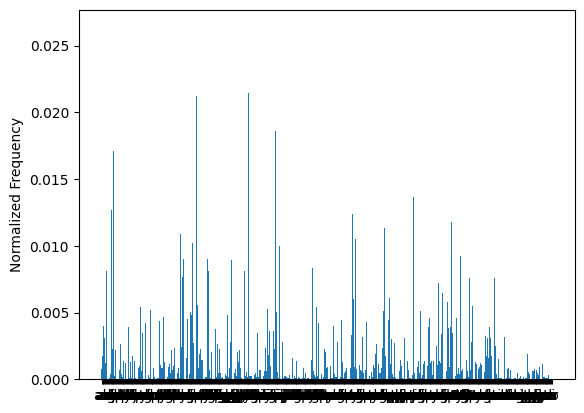

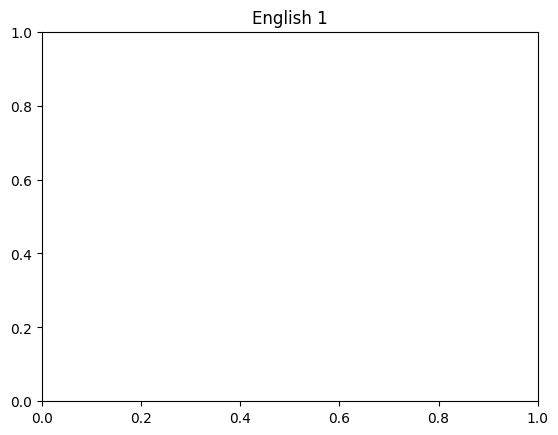

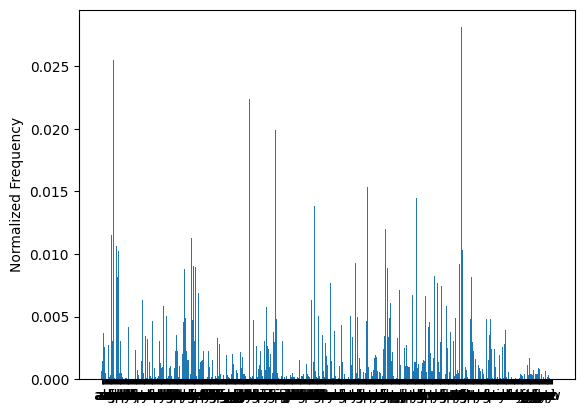

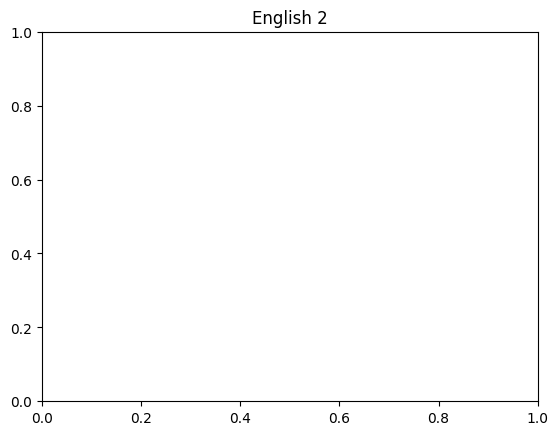

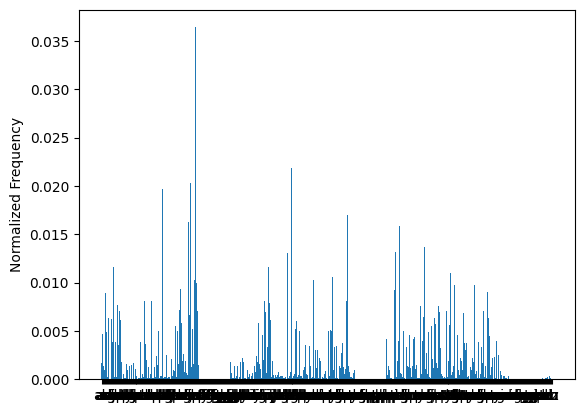

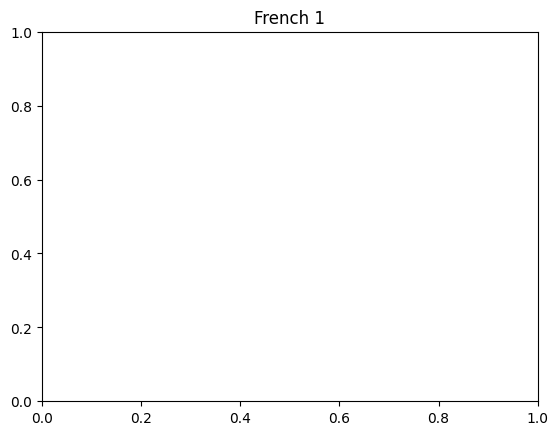

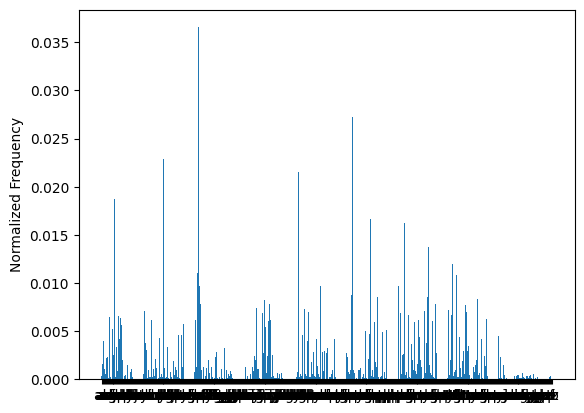

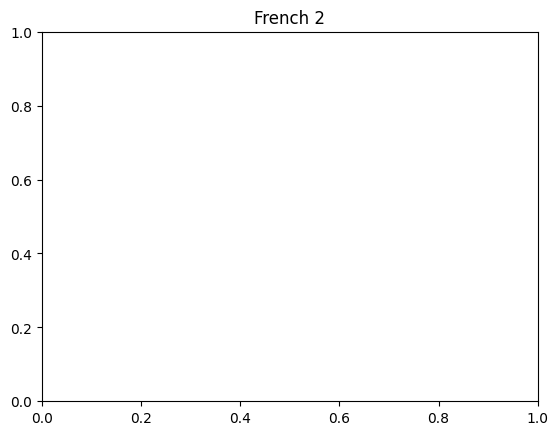

In [ ]:
texts = [eng1, eng2, fr1, fr2]
titles = ["English 1", "English 2", "French 1", "French 2"]

for text, title in zip(texts, titles):
    bigram = Counter(ngrams(text, 2))
    plothistogram(bigram)
    plt.title(title)
    plt.show()

Another way to visualize bigrams is to use a 2-dimensional graph.

In [ ]:
def plotbihistogram(ngram):
    freq = np.zeros((26, 26))
    for (a, b), count in ngram.items():
        i = ord(a) - ord('a')
        j = ord(b) - ord('a')
        freq[i, j] = count
    plt.imshow(freq, cmap='jet')
    plt.colorbar()
    plt.show()
    return freq

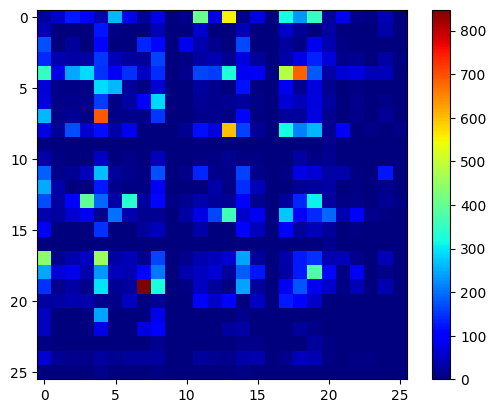

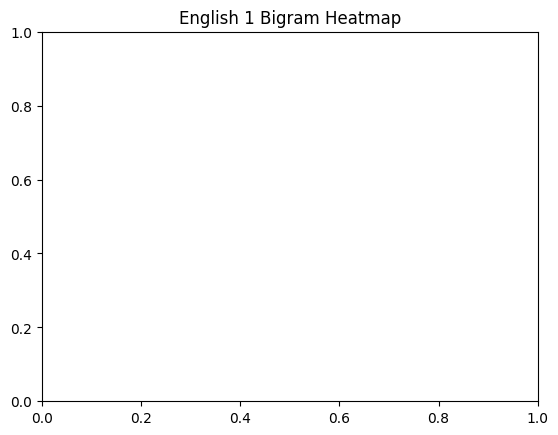

In [ ]:
bieng1 = plotbihistogram(bigram_eng1)
plt.title("English 1 Bigram Heatmap")
plt.show()

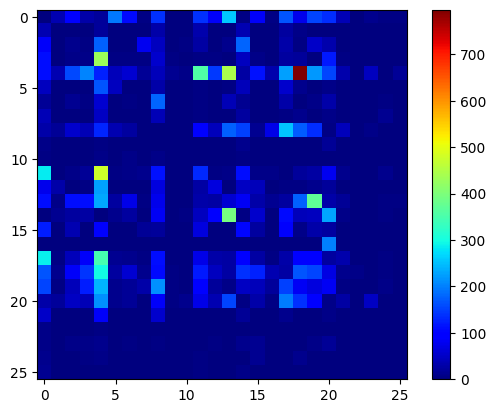

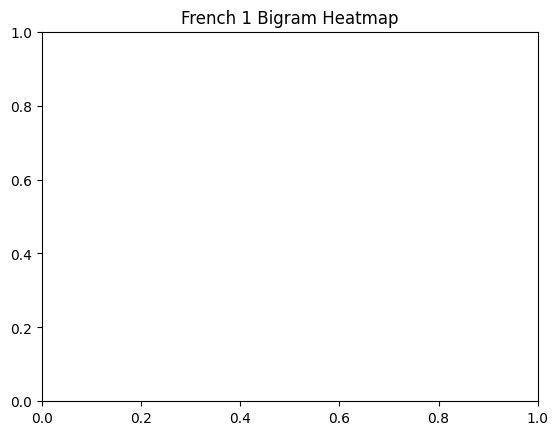

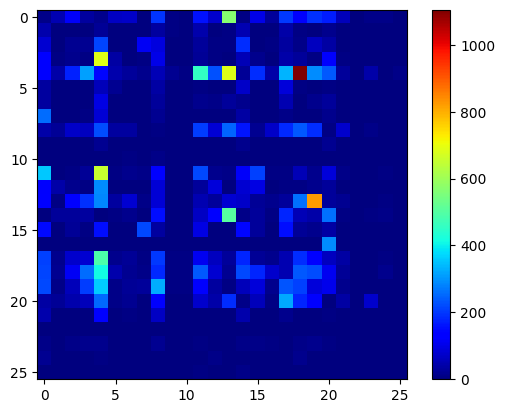

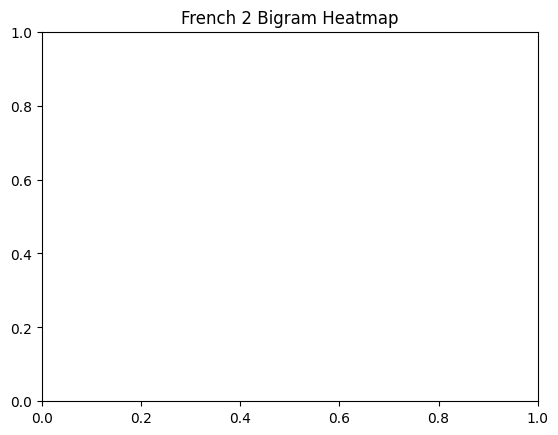

In [ ]:
bifr1 = plotbihistogram(bigram_fr1)
plt.title("French 1 Bigram Heatmap")
plt.show()

bifr2 = plotbihistogram(bigram_fr2)
plt.title("French 2 Bigram Heatmap")
plt.show()

Let us look at the top 10 ngrams for each text.

In [ ]:
def ind2tup(ind):
    i, j = divmod(int(ind), 26)
    return (chr(ord('a') + i), chr(ord('a') + j))
def ShowTopN(bifreq, n=10):
    f = bifreq.flatten()
    top_indices = np.argsort(f)[::-1][:n]
    for idx in top_indices:
        print(f"{ind2tup(idx)} : {f[idx]}")

In [ ]:
print("\nEnglish 1:")
ShowTopN(bieng1)
print("\nEnglish 2:")
ShowTopN(bieng2)
print("\nFrench 1:")
ShowTopN(bifr1)
print("\nFrench 2:")
ShowTopN(bifr2)


English 1:
('t', 'h') : 848.0
('h', 'e') : 690.0
('e', 's') : 683.0
('i', 'n') : 598.0
('a', 'n') : 550.0
('e', 'r') : 482.0
('r', 'e') : 455.0
('r', 'a') : 438.0
('a', 'l') : 407.0
('n', 'd') : 397.0

English 2:
('t', 'h') : 1251.0
('a', 'n') : 1134.0
('h', 'e') : 997.0
('i', 'n') : 885.0
('n', 't') : 682.0
('e', 'r') : 662.0
('e', 's') : 656.0
('r', 'e') : 644.0
('h', 'a') : 628.0
('l', 'e') : 615.0

French 1:
('e', 's') : 796.0
('l', 'e') : 478.0
('e', 'n') : 444.0
('d', 'e') : 430.0
('o', 'n') : 392.0
('n', 't') : 372.0
('e', 'l') : 355.0
('r', 'e') : 346.0
('s', 'e') : 298.0
('r', 'a') : 287.0

French 2:
('e', 's') : 1105.0
('n', 't') : 823.0
('d', 'e') : 690.0
('e', 'n') : 686.0
('l', 'e') : 652.0
('a', 'n') : 566.0
('o', 'n') : 504.0
('r', 'e') : 492.0
('e', 'l') : 456.0
('s', 'e') : 414.0


We observe that the bigrams are similar across different topics but different across languages. Thus, the bigram frequency is a good feature for distinguishing languages, but not for distinguishing topics.

Thus, we were able to convert a many-dimensional input (the text) to 26 dimesions (unigrams) or 26*26 dimensions (bigrams).


A few ways to explore:
1. Try with different languages.
2. The topics we used are quite similar, wikipedia articles of 'elephant' and 'giraffe'. What happens if we use very different topics? What if we use text from another source than Wikipedia?
3. How can we use and visualize trigrams and higher n-grams?

# Part 2: Written numbers

We will use a subset of the MNIST dataset. Each input character is represented in a 28*28 array. Let us see if we can extract some simple features from these images which can help us distinguish between the digits.

Load the dataset:

In [ ]:
from keras.datasets import mnist

#loading the dataset
(train_X, train_y), (test_X, test_y) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extract a subset of the data for our experiment:

In [ ]:
no1 = train_X[train_y==1,:,:]
no0 = train_X[train_y==0,:,:]

Let us visualize a few images here:

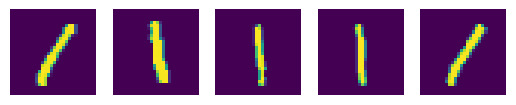

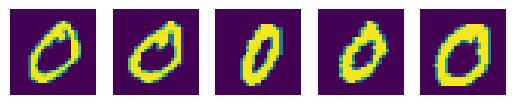

In [ ]:
fig, axes = plt.subplots(1, 5)
for ii in range(5):
    axes[ii].imshow(no1[ii, :, :])
    axes[ii].axis('off')
plt.show()
fig, axes = plt.subplots(1, 5)
for ii in range(5):
    axes[ii].imshow(no0[ii, :, :])
    axes[ii].axis('off')
plt.show()

suNow, let us start with a simple feature: the sum of all pixels and see how good this feature is.

In [ ]:
sum1 = np.sum(no1>0, (1,2)) # threshold before adding up
sum0 = np.sum(no0>0, (1,2))

Let us visualize how good this feature is: (X-axis is mean, y-axis is the digit)

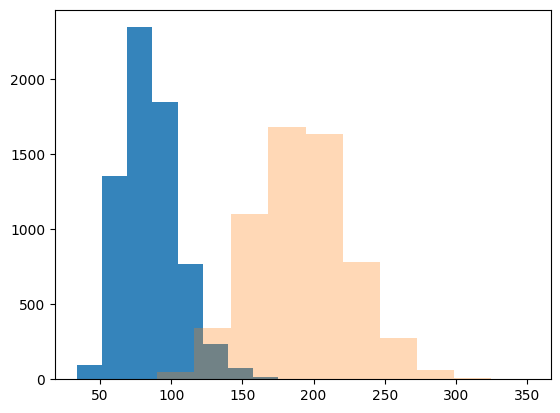

In [ ]:
plt.hist(sum1, alpha=0.9);
plt.hist(sum0, alpha=0.3);

We can already see that this feature separates the two classes quite well.

Let us look at another, more complicated feature. We will count the number black pixels that are surrounded on four sides by non-black pixels, or "hole pixels".

In [ ]:
def cumArray(img):
    img2 = img.copy()
    rows = img2.shape[0]
    for r in range(1, rows):
        img2[r] += img2[r-1]
    return img2 > 0
def getHolePixels(img):
    directions = []
    for k in range(4):
        rotated = np.rot90(img, k)
        filled = cumArray(rotated)
        directions.append(np.rot90(filled, -k))
    hull = directions[0] & directions[1] & directions[2] & directions[3]
    hole = hull & ~(img > 0)
    return hole

Visualize a few:

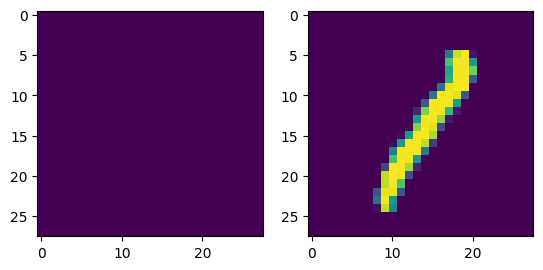

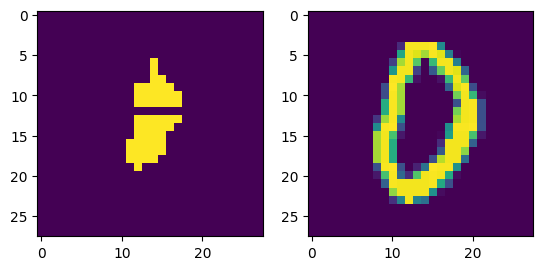

In [ ]:
imgs = [no1[456, :, :], no0[457, :, :]]
for img in imgs:
    plt.subplot(1, 2, 1)
    plt.imshow(getHolePixels(img))
    plt.subplot(1, 2, 2)
    plt.imshow(img)
    plt.show()

Now let us plot the number of hole pixels and see how this feature behaves

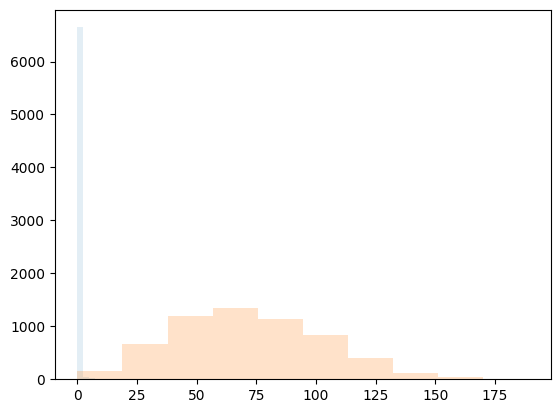

In [ ]:
hole1 = np.array([getHolePixels(i).sum() for i in no1])
hole0 = np.array([getHolePixels(i).sum() for i in no0])

plt.hist(hole1, alpha=0.12);
plt.hist(hole0, alpha=0.22);

This feature works even better to distinguish between one and zero.


Now let us try the number of pixels in the 'hull' or the number with the holes filled in:

In [ ]:
def getHullPixels(img):
  im1 = cumArray(img)
  im2 = np.rot90(cumArray(np.rot90(img)), 3) # rotate and cumulate it again for differnt direction
  im3 = np.rot90(cumArray(np.rot90(img, 3)), 2)
  im4 = np.rot90(cumArray(np.rot90(img, 3)), 1)
  hull =  im1 & im2 & im3 & im4 # this will create a binary image with all the holes filled in.
  return hull

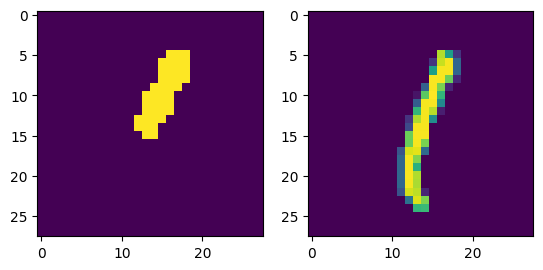

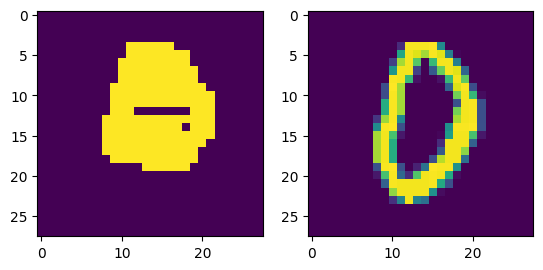

In [ ]:
imgs = [no1[458,:,:],  no0[457,:,:]]
for img in imgs:
  plt.subplot(1,2,1)
  plt.imshow(getHullPixels(img))
  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.show()

Plotting the number of hull pixels versus the digit:

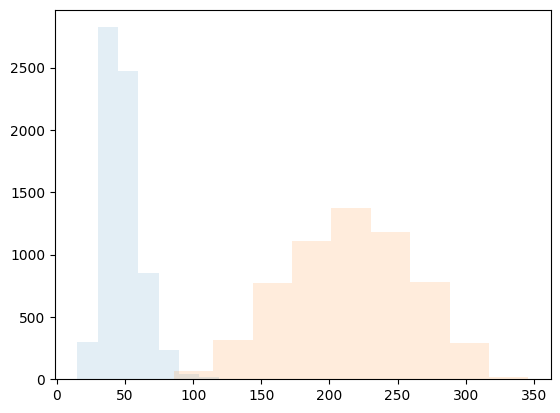

In [ ]:
hull1 = np.array([getHullPixels(i).sum() for i in no1])
hull0 = np.array([getHullPixels(i).sum() for i in no0])

plt.hist(hull1, alpha=0.12);
plt.hist(hull0, alpha=0.14);

Let us try one more feature, where we look at the number of boundary pixels in each image.

In [ ]:
def minus(a, b):
  return a & ~ b

def getBoundaryPixels(img):
  img = img.copy()>0  # binarize the image
  rshift = np.roll(img, 1, -1)
  lshift = np.roll(img, 1 ,-1)
  ushift = np.roll(img, 1, -2)
  dshift = np.roll(img, 1, -4)
  boundary = minus(img, rshift) | minus(img, lshift) | minus(img, ushift) | minus(img, dshift)
  return boundary

In [ ]:
def getBoundaryPixels(img):
    rshift = np.roll(img, 1, axis=1)
    lshift = np.roll(img, -1, axis=1)
    ushift = np.roll(img, -1, axis=0)
    dshift = np.roll(img, 1, axis=0)
    boundary = (img != rshift) | (img != lshift) | (img != ushift) | (img != dshift)
    return boundary

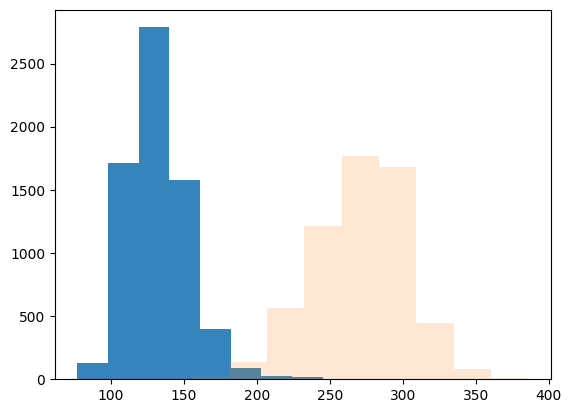

In [ ]:
bound1 = np.array([getBoundaryPixels(i).sum() for i in no1])
bound0= np.array([getBoundaryPixels(i).sum() for i in no0])

plt.hist(bound1, alpha=0.9);
plt.hist(bound0, alpha=0.18);

What will happen if we plot two features together?

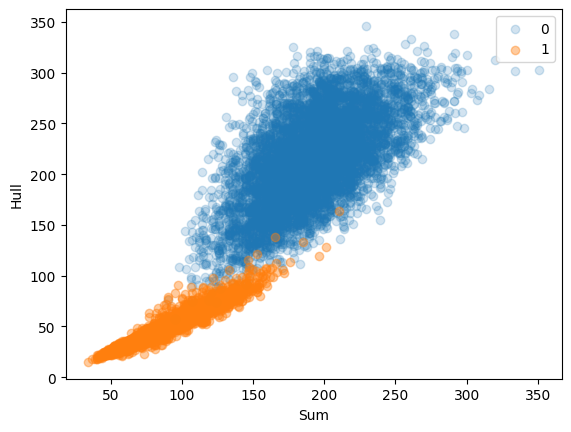

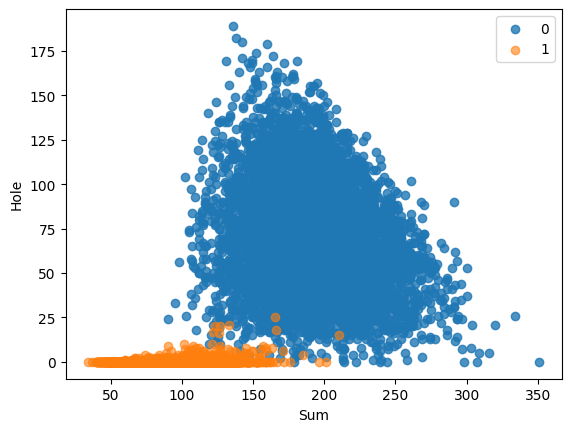

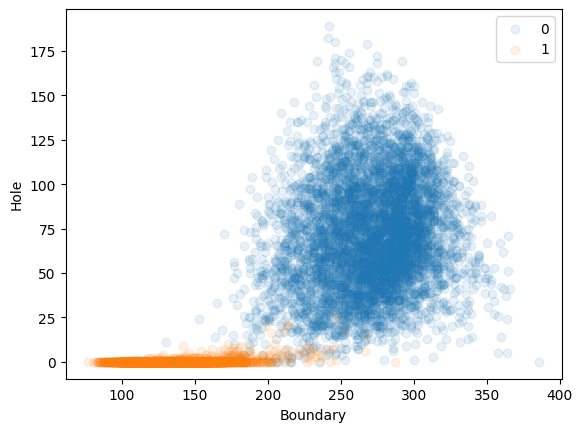

In [ ]:
# Sum and hull
plt.scatter(sum0, hull0, alpha=0.2)
plt.scatter(sum1, hull1, alpha=0.4)
plt.xlabel('Sum')
plt.ylabel('Hull')
plt.legend(['0','1'])
plt.show()

# Sum and hole
plt.scatter(sum0, hole0, alpha=0.8)
plt.scatter(sum1, hole1, alpha=0.6)
plt.xlabel('Sum');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

# Hole and boundary
plt.scatter(bound0, hole0, alpha=0.1)
plt.scatter(bound1, hole1, alpha=0.1)
plt.xlabel('Boundary');
plt.ylabel('Hole');
plt.legend(['0','1'])
plt.show()

Now let us try plotting 3 features together.

In [ ]:
cl1 = ['Class 1'] * len(sum1)
cl0 = ['Class 0'] * len(sum0)
df = pd.DataFrame(
    list(zip(
        np.concatenate((hole1, hole0)),
        np.concatenate((sum1, sum0)),
        np.concatenate((bound1, bound0)),
        np.concatenate((cl1, cl0))
    )),
    columns=['Hole', 'Sum', 'Boundary', 'Class']
)
df.head()
fig = px.scatter_3d(
    df,
    x='Hole',
    y='Sum',
    z='Boundary',
    color='Class',
    opacity=0.6
)
fig.show()

Feel free to explore the above graph with your mouse.


We have seen that we extracted four features from a 28*28 dimensional image.


Some questions to explore:
1. Which is the best combination of features?
2. How would you test or visualize four or more features?
3. Can you come up with your own features?
4. Will these features work for different classes other than 0 and 1?
5. What will happen if we take more that two classes at a time?


### Answers

1. Which is the best combination of features?
The best combination of features is the one that clearly separates different classes in the feature space. When features create distinct clusters for each class, the model can easily distinguish between them and achieve better classification accuracy.

2. How would you test or visualize four or more features?
To test or visualize four or more features, we can use dimensionality reduction and visualization techniques such as Principal Component Analysis (PCA), t-SNE, or pair plots.

3. Can you come up with your own features?
Yes, we can create our own features using feature engineering such as calculating average pixel intensity, edge detection values, or shape-based features.

4. Will these features work for different classes other than 0 and 1?
Yes, these features can also work for other classes. However, their effectiveness depends on how well they separate the new classes.

5. What will happen if we take more than two classes at a time?
If we take more than two classes at a time, the problem becomes a multi-class classification problem, where the model must learn multiple decision boundaries.


### Conclusion
In this lab, we explored how to extract meaningful features from image data and how different feature combinations help in classification tasks. Feature engineering and proper visualization techniques improve machine learning model performance.